# Single-transfer trajectory examples

This notebook solves one fixed Earth-to-Mars transfer with no departure-date or transfer-time grid. It compares:

1. The six-degree-of-freedom high-order hodographic basis reported by Gondelach and Noomen.
2. A quintic cylindrical B-spline with 10 control points.

Both examples use departure MJD2000 = 9000, a 1200-day time of flight, and revolution branch $N=1$. The built-in Keplerian ephemeris is used so the notebook runs from a clean repository checkout without external SPICE binary kernels. Publication campaigns should use the SPICE options documented by the command-line scripts.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if not (ROOT / "experiments").exists():
    ROOT = ROOT.parent
if not (ROOT / "experiments").exists():
    raise RuntimeError("Run this notebook from the FASTTRANSFER repository or notebooks directory.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from experiments.postprocess_compare_gondelach_plots import evaluate_time_driven_profile
from experiments.reproduce_gondelach_fig2 import ELEMENTS, configure_ephemeris, planet_state
from experiments.reproduce_gondelach_fig2_bspline_cylindrical import solve_one
from experiments.reproduce_gondelach_fig3 import FIG3_BASIS, optimize_grid_point
from optimizer.canonical_units import accel_array_from_canonical
from optimizer.helpers_Bspline import build_bspline_matrices
from optimizer.optimization_Bspline_freetf import evaluate_cylindrical_profile

configure_ephemeris("kepler")

DEPARTURE_MJD2000 = 9000.0
TOF_DAYS = 1200.0
N_REV = 1
TARGET = "mars"

AU_M = 149_597_870_700.0
YEAR_S = 365.25 * 86400.0

earth_departure, _ = planet_state("earth", DEPARTURE_MJD2000)
target_arrival, _ = planet_state(TARGET, DEPARTURE_MJD2000 + TOF_DAYS)

earth_period_days = 365.25 * ELEMENTS["earth"].a**1.5
mars_period_days = 365.25 * ELEMENTS["mars"].a**1.5
earth_orbit_epochs = DEPARTURE_MJD2000 + np.linspace(0.0, earth_period_days, 500)
mars_orbit_epochs = DEPARTURE_MJD2000 + TOF_DAYS + np.linspace(-mars_period_days, 0.0, 500)
earth_orbit_arc = np.vstack([planet_state("earth", epoch)[0] for epoch in earth_orbit_epochs])
mars_orbit_arc = np.vstack([planet_state("mars", epoch)[0] for epoch in mars_orbit_epochs])

plt.rcParams.update({"font.size": 12, "axes.grid": True, "grid.alpha": 0.25})

In [2]:
def plot_trajectory_and_control(title, position_au, time_days, control_m_s2, delta_v_km_s):
    fig = plt.figure(figsize=(15.0, 5.3), constrained_layout=True)
    grid = fig.add_gridspec(1, 2, width_ratios=(1.25, 1.0))
    ax_trajectory = fig.add_subplot(grid[0, 0], projection="3d")
    ax_control = fig.add_subplot(grid[0, 1])

    ax_trajectory.plot(
        earth_orbit_arc[:, 0], earth_orbit_arc[:, 1], earth_orbit_arc[:, 2],
        color="tab:cyan", linestyle="--", linewidth=1.3, alpha=0.8, label="Earth orbit",
    )
    ax_trajectory.plot(
        mars_orbit_arc[:, 0], mars_orbit_arc[:, 1], mars_orbit_arc[:, 2],
        color="tab:red", linestyle="--", linewidth=1.3, alpha=0.8, label="Mars orbit",
    )
    ax_trajectory.plot(
        position_au[:, 0], position_au[:, 1], position_au[:, 2],
        color="b", linewidth=2.2, label="Low-thrust trajectory",
    )
    ax_trajectory.scatter(0.0, 0.0, 0.0, s=80, color="gold", edgecolor="black", label="Sun", zorder=4)
    ax_trajectory.scatter(
        earth_departure[0], earth_departure[1], earth_departure[2],
        s=55, color="tab:blue", label="Earth departure", zorder=4,
    )
    ax_trajectory.scatter(
        target_arrival[0], target_arrival[1], target_arrival[2],
        s=55, color="tab:red", label="Mars arrival", zorder=4,
    )
    ax_trajectory.set_xlabel("$x$ [AU]")
    ax_trajectory.set_ylabel("$y$ [AU]")
    ax_trajectory.set_zlabel("$z$ [AU]")
    ax_trajectory.set_xlim(-2.1, 2.1)
    ax_trajectory.set_ylim(-2.1, 2.1)
    ax_trajectory.set_zlim(-0.25, 0.25)
    ax_trajectory.set_box_aspect((1.0, 1.0, 0.45))
    ax_trajectory.view_init(elev=26, azim=-55)
    ax_trajectory.legend(fontsize=8.5, loc="upper left")
    ax_trajectory.set_title("3D trajectory", y=1.03)

    labels = (r"$u_r$", r"$u_\theta$", r"$u_z$")
    colors = ("tab:red", "tab:green", "tab:blue")
    for component, label, color in zip(control_m_s2.T, labels, colors):
        ax_control.plot(time_days, 1000.0 * component, label=label, color=color, linewidth=1.8)
    ax_control.set_xlabel("Time since departure [days]")
    ax_control.set_ylabel("Thrust acceleration [mm/s$^2$]")
    ax_control.legend(fontsize=10)
    ax_control.set_title(rf"Control ($\Delta V={delta_v_km_s:.3f}$ km/s)")

    fig.suptitle(title, fontsize=14)
    plt.show()

## High-order hodographic solution

Only the six free high-order coefficients of the selected $N=1$ branch are optimized. The boundary-condition coefficients are reconstructed analytically from the basis functions.

In [3]:
gondelach_result = optimize_grid_point(
    dep=DEPARTURE_MJD2000,
    tof=TOF_DAYS,
    n_rev=N_REV,
    target=TARGET,
    basis=FIG3_BASIS,
    n_quad=801,
    x0=np.zeros(6),
    maxfev=1200,
    xatol=1.0e-7,
    fatol=1.0e-7,
    simplex_scale=0.05,
    optimizer="scipy",
)
if not gondelach_result["usable"]:
    raise RuntimeError(gondelach_result["message"])

gondelach_profile = evaluate_time_driven_profile(
    DEPARTURE_MJD2000,
    TOF_DAYS,
    N_REV,
    1001,
    FIG3_BASIS,
    gondelach_result["free_coefficients"],
    TARGET,
)

print(f"Optimizer success: {gondelach_result['optimizer_success']}")
print(f"Function evaluations: {gondelach_result['nfev']}")
print(f"Delta V: {gondelach_profile['delta_v_km_s']:.6f} km/s")
print(f"Maximum thrust acceleration: {1000.0 * gondelach_profile['fmax_m_s2']:.6f} mm/s^2")

Optimizer success: True
Function evaluations: 560
Delta V: 9.393000 km/s
Maximum thrust acceleration: 0.203008 mm/s^2


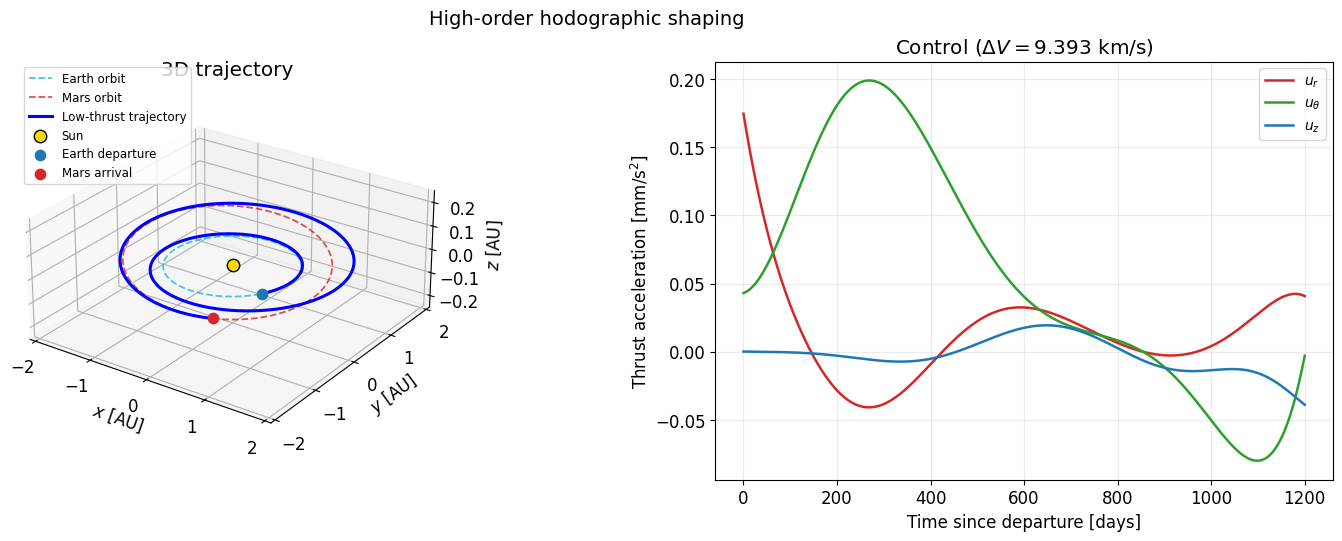

In [4]:
plot_trajectory_and_control(
    "High-order hodographic shaping",
    gondelach_profile["pos_au"],
    gondelach_profile["t_days"],
    gondelach_profile["u_components_m_s2"],
    gondelach_profile["delta_v_km_s"],
)

## Quintic cylindrical B-spline

The B-spline uses 10 control points. The first two and last two control points are eliminated analytically from the position and velocity boundary conditions. The remaining control points minimize Delta V using sixth-order Gauss-Legendre quadrature.

In [5]:
N_CONTROL_POINTS = 10
DEGREE = 5
N_FINE = 1001

bspline_options = {
    "ephemeris": "kepler",
    "spice_meta_kernel": "",
    "spice_target_name": "",
    "target": TARGET,
    "n_ctrl": N_CONTROL_POINTS,
    "degree": DEGREE,
    "n_fine": N_FINE,
    "seed_profile": "quintic",
    "quadrature_order": 6,
    "r_bound": 20.0,
    "dv_eps": 1.0e-6,
    "smoothness_weight": 0.0,
    "endpoint_control_weight": 0.0,
    "max_iter": 700,
    "print_level": 0,
    "kepler_substeps": 80,
    "accept_debug_feasible": False,
    "endpoint_tol": 1.0e-6,
    "winding_tol_rev": 1.0e-3,
}

bspline_result = solve_one(DEPARTURE_MJD2000, TOF_DAYS, N_REV, bspline_options)
if not bspline_result["usable"]:
    raise RuntimeError(bspline_result["message"])

bspline_matrices = build_bspline_matrices(N_CONTROL_POINTS, DEGREE, N_FINE)
bspline_profile = evaluate_cylindrical_profile(
    bspline_result["control_points"],
    bspline_matrices,
    bspline_result["t_transfer_canonical"],
    bspline_result["mu"],
)

theta = bspline_profile["q_cyl"][:, 1]
u_cartesian_m_s2 = (
    accel_array_from_canonical(bspline_profile["u"]) * AU_M / YEAR_S**2
)
bspline_control_m_s2 = np.column_stack(
    [
        u_cartesian_m_s2[:, 0] * np.cos(theta) + u_cartesian_m_s2[:, 1] * np.sin(theta),
        -u_cartesian_m_s2[:, 0] * np.sin(theta) + u_cartesian_m_s2[:, 1] * np.cos(theta),
        u_cartesian_m_s2[:, 2],
    ]
)

print(f"Formal optimizer success: {bspline_result['success']}")
print(f"IPOPT iterations: {bspline_result['ipopt_iterations']}")
print(f"Delta V: {bspline_result['delta_v_km_s']:.6f} km/s")
print(f"Endpoint residual: {bspline_result['endpoint_error']:.3e}")
print(f"Winding residual: {bspline_result['winding_error_rev']:.3e} revolutions")


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Formal optimizer success: True
IPOPT iterations: 27
Delta V: 6.948630 km/s
Endpoint residual: 2.932e-15
Winding residual: 2.827e-16 revolutions


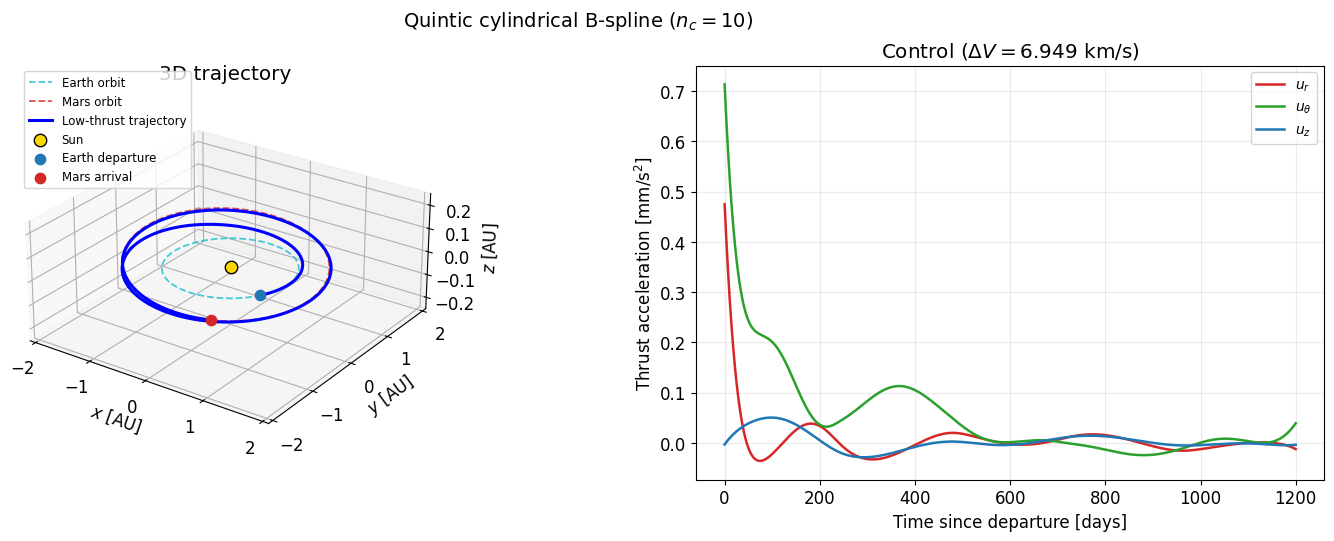

In [6]:
plot_trajectory_and_control(
    "Quintic cylindrical B-spline ($n_c=10$)",
    bspline_profile["pos"],
    bspline_profile["tau"] * TOF_DAYS,
    bspline_control_m_s2,
    bspline_result["delta_v_km_s"],
)